In [1]:
# initializing model

import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq
load_dotenv()

llm = ChatGroq(model = "openai/gpt-oss-120b")

response = llm.invoke("hello what is today date and time?")
print(response.content)

The current date is **2026‑08‑18**. I don’t have access to the exact current time at the moment.


In [2]:
# schema of state

from typing_extensions import TypedDict
class State(TypedDict):
    application:str
    experience_level:str
    skill_match: str
    response:str

In [3]:
# flow/ Start and end

from langgraph.graph import StateGraph, START,END
workflow = StateGraph(State)

In [4]:
# defining node function

from langchain_core.prompts import ChatPromptTemplate
def categorize_experience(state: State)->State:
    print("\n categorizing the experience level of candidate: ")
    prompt = ChatPromptTemplate.from_template("Based on the following job application, categorize the candidate as 'Entry-level', 'Mid-level' or 'Senior-level'"
    "Application : {application}")

    chain = prompt | llm
    experience_level = chain.invoke({"application": state["application"]}).content
    print(f"Experience Level : {experience_level}")
    return {"experience_level": experience_level}

def assess_skillset(state: State)->State:
    print("/nAssessing the skillset of candidate : ")
    prompt = ChatPromptTemplate.from_template(
        "Based on the job application for a Python developer, access the candidate skillset"
        " Response with either 'Match' or 'No Match'"
        "Application : {application}"
    )
    chain = prompt | llm
    skill_match = chain.invoke({"application": state["application"]}).content
    print(f"Skill Match : {skill_match}")
    return {"skill_match": skill_match}

def schedule_hr_interview(state: State)-> State:
    print("\n Scheduling the inteview : ")
    return {"response": "Candidate has been Shortlisted for HR interview."}

def escalate_to_recuriter(state: State)-> State:
    print("Escalating to recruiter")
    return {"response": " Candidate has senior-level experience but does not match job skills."}

def reject_application(state: State)-> State:
    print("sending rejection mail")
    return {"response": " Candidate doesn't meet JD and has been rejected."}




In [5]:
# adding node to workflow

workflow.add_node("categorize_experience", categorize_experience)
workflow.add_node("assess_skillset", assess_skillset)
workflow.add_node("schedule_hr_interview", schedule_hr_interview)
workflow.add_node("escalate_to_recuriter", escalate_to_recuriter)
workflow.add_node("reject_application", reject_application)

In [6]:
# Nodes (like categorize_experience and assess_skillset) do the work and update the state.
# route_app is a Conditional Router (Decision Maker). It does not modify data; instead, it looks at the current state and decides which node to go to next

def route_app(state: State) -> str:
    skill = state.get("skill_match", "").lower()
    exp = state.get("experience_level", "").lower()
    if "match" in skill and "no match" not in skill:
        return "schedule_hr_interview"
    elif "senior" in exp:
        return "escalate_to_recuriter"
    else:
        return "reject_application"

In [7]:
# adding edge(connecting/wiring between nodes)
workflow.add_edge(START, "categorize_experience")
workflow.add_edge("categorize_experience", "assess_skillset")
# Pass the routing map so LangGraph visualizes all 3 branches cleanly:
workflow.add_conditional_edges(
    "assess_skillset",
    route_app,
    {
        "schedule_hr_interview": "schedule_hr_interview",
        "escalate_to_recuriter": "escalate_to_recuriter",
        "reject_application": "reject_application"
    }
)
workflow.add_edge("escalate_to_recuriter",END)
workflow.add_edge("reject_application",END)
workflow.add_edge("schedule_hr_interview",END)

In [8]:
app = workflow.compile()

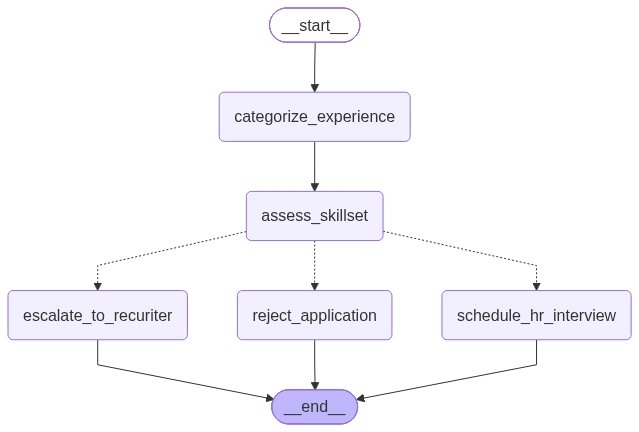

In [9]:
from IPython.display import Image, display

display(
    Image(
        app.get_graph().draw_mermaid_png()
    )
)

In [10]:
# running application/ testing

def run_candidate_screening(application: str):
    results = app.invoke({"application": application})
    return{
        "experience_level" : results["experience_level"],
        "skill_match": results["skill_match"],
        "response": results["response"]
    }

In [11]:
# testing with example
application_text = "I have 10 years of experience in software engineering with expertise in JAVA"
results = run_candidate_screening(application_text)
print("\n\nComputed Results : ")
print(f"Application: {application_text}")
print(f"Experience Level: {results['experience_level']}")
print(f"Skill Match: {results['skill_match']}")
print(f"Response: {results['response']}")


 categorizing the experience level of candidate: 
Experience Level : **Senior-level**
/nAssessing the skillset of candidate : 
Skill Match : No Match
Escalating to recruiter


Computed Results : 
Application: I have 10 years of experience in software engineering with expertise in JAVA
Experience Level: **Senior-level**
Skill Match: No Match
Response:  Candidate has senior-level experience but does not match job skills.


In [12]:
application_text = "I have 1 years of experience in software engineering with expertise in JAVA"
results = run_candidate_screening(application_text)
print("\n\nComputed Results : ")
print(f"Application: {application_text}")
print(f"Experience Level: {results['experience_level']}")
print(f"Skill Match: {results['skill_match']}")
print(f"Response: {results['response']}")


 categorizing the experience level of candidate: 
Experience Level : **Entry-level**
/nAssessing the skillset of candidate : 
Skill Match : No Match
sending rejection mail


Computed Results : 
Application: I have 1 years of experience in software engineering with expertise in JAVA
Experience Level: **Entry-level**
Skill Match: No Match
Response:  Candidate doesn't meet JD and has been rejected.


In [13]:
application_text = "I have years of experience in software engineering with expertise in Python"
results = run_candidate_screening(application_text)
print("\n\nComputed Results : ")
print(f"Application: {application_text}")
print(f"Experience Level: {results['experience_level']}")
print(f"Skill Match: {results['skill_match']}")
print(f"Response: {results['response']}")


 categorizing the experience level of candidate: 
Experience Level : **Mid-level** – The statement “I have years of experience in software engineering with expertise in Python” indicates more than just entry‑level exposure, but without specific details (e.g., 8‑10+ years, leadership roles, large‑scale architecture responsibilities) that would point to a senior position. Hence, the most appropriate categorization is mid‑level.
/nAssessing the skillset of candidate : 
Skill Match : Match

 Scheduling the inteview : 


Computed Results : 
Application: I have years of experience in software engineering with expertise in Python
Experience Level: **Mid-level** – The statement “I have years of experience in software engineering with expertise in Python” indicates more than just entry‑level exposure, but without specific details (e.g., 8‑10+ years, leadership roles, large‑scale architecture responsibilities) that would point to a senior position. Hence, the most appropriate categorization is 